In [4]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

from exact import simulate
from ryd_gate import DEFAULT_C6, RydbergSystem
from ryd_gate.lattice import make_square_lattice
from ryd_gate.core.rydberg_system import InteractionSpec
from ryd_gate.protocols.digital_analog import DigitalAnalogProtocol, Segment
from tenpy_mps import mps_fidelity, product_superposition_mps



The whole Hamiltonian is:
$$
\begin{align*}
&H(t)/\hbar =
\sum_i \frac{\Omega_{R,i}(t)}{2}
\left(|r_i\rangle\langle 1_i|+\mathrm{h.c.}\right)
-\sum_i \Delta_{R,i}(t) n_i^r\\
&+
\sum_i \frac{\Omega_{\rm hf,i}(t)}{2}
\left(|1_i\rangle\langle0_i|+\mathrm{h.c.}\right)
-\sum_i \Delta_{\rm hf,i}(t) n_i^1
+
\sum_{i<j}V_{ij}n_i^r n_j^r ,
\end{align*}
$$

Considering $\Omega_R \equiv \Omega_{\text{eff}}=\frac{\Omega_{420}\Omega_{1013}}{2|\Delta|}$

- If we use（`Ω420/2π=237 MHz`, `Ω1013/2π=303 MHz`, `Δ/2π=7.8 GHz`）：$\Omega_R/2\pi \approx 4.60\ \text{MHz}$
- If we use（`Ω420≈Ω1013≈135 MHz`, `Δ≈2.4 GHz`）：$\Omega_R/2\pi \approx 3.80\ \text{MHz}$

`OMEGA_R = 2*np.pi*(3.1e6 ~ 6.0e6)` is thus a appropriate range

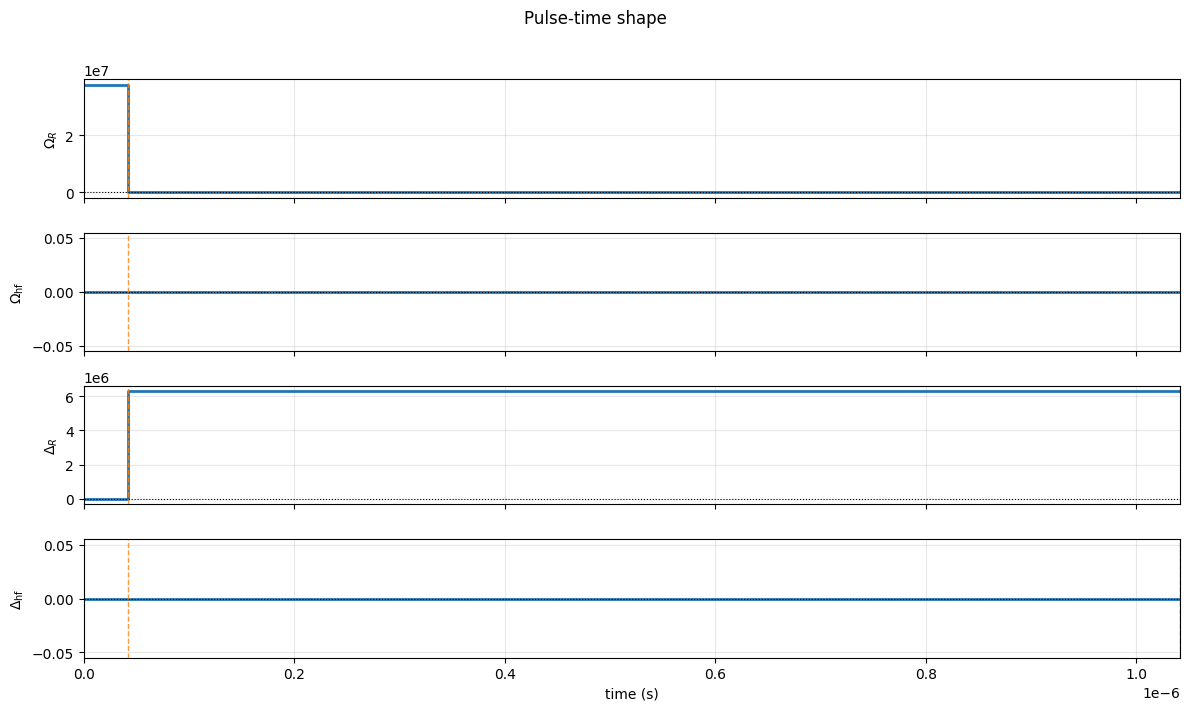

In [ ]:
# Plus preparation
OMEGA_R = 2 * np.pi * 6e6
OMEGA_HF = 2 * np.pi * 6e6

t_pi_R = np.pi / OMEGA_R
t_pi2_R = np.pi / (2 * OMEGA_R)

# Ising evolution controls (only delta_R is kept)
DELTA_R_ISING = 2 * np.pi * 1.0e6
T_ISING = 1.0e-6

# Pulse-time shape over full process: prep segment then Ising segment
full_segments = [
    Segment(duration=t_pi2_R, omega_R=OMEGA_R),
    Segment(
        duration=T_ISING,
        omega_R=0.0,
        omega_hf=0.0,
        delta_R=DELTA_R_ISING,
        delta_hf=0.0,
    ),
]


# Pulse-time shape (full_segments schedule)
t_prep_end = full_segments[0].duration
t_final = sum(seg.duration for seg in full_segments)

_proto_fields = (
    ("omega_R", r"$\Omega_R$"),
    ("omega_hf", r"$\Omega_{\rm hf}$"),
    ("delta_R", r"$\Delta_R$"),
    ("delta_hf", r"$\Delta_{\rm hf}$"),
)

_t_edges = [0.0]
for seg in full_segments:
    _t_edges.append(_t_edges[-1] + seg.duration)

fig_p, axes_p = plt.subplots(4, 1, figsize=(12, 7), sharex=True)
for ax_p, (field, label) in zip(axes_p, _proto_fields):
    t_pts, y_pts = [], []
    for j, seg in enumerate(full_segments):
        v = getattr(seg, field)
        t_pts.extend([_t_edges[j], _t_edges[j + 1]])
        y_pts.extend([v, v])
    ax_p.step(t_pts, y_pts, where="post", lw=2, color="tab:blue")
    ax_p.axhline(0.0, color="k", ls=":", lw=0.8)
    ax_p.axvline(t_prep_end, color="tab:orange", ls="--", lw=1, alpha=0.8)
    ax_p.set_ylabel(label)
    ax_p.grid(alpha=0.3)
    ax_p.set_xlim(0.0, t_final)

axes_p[-1].set_xlabel("time (s)")
axes_p[-1].axvline(t_final, color="tab:green", ls="--", lw=1, alpha=0.8)
fig_p.suptitle("Pulse-time shape", y=1.01)
plt.tight_layout()
plt.show()


N=9, prep-end fidelity to (|1> - i|r>)/sqrt(2)^9: 0.9639


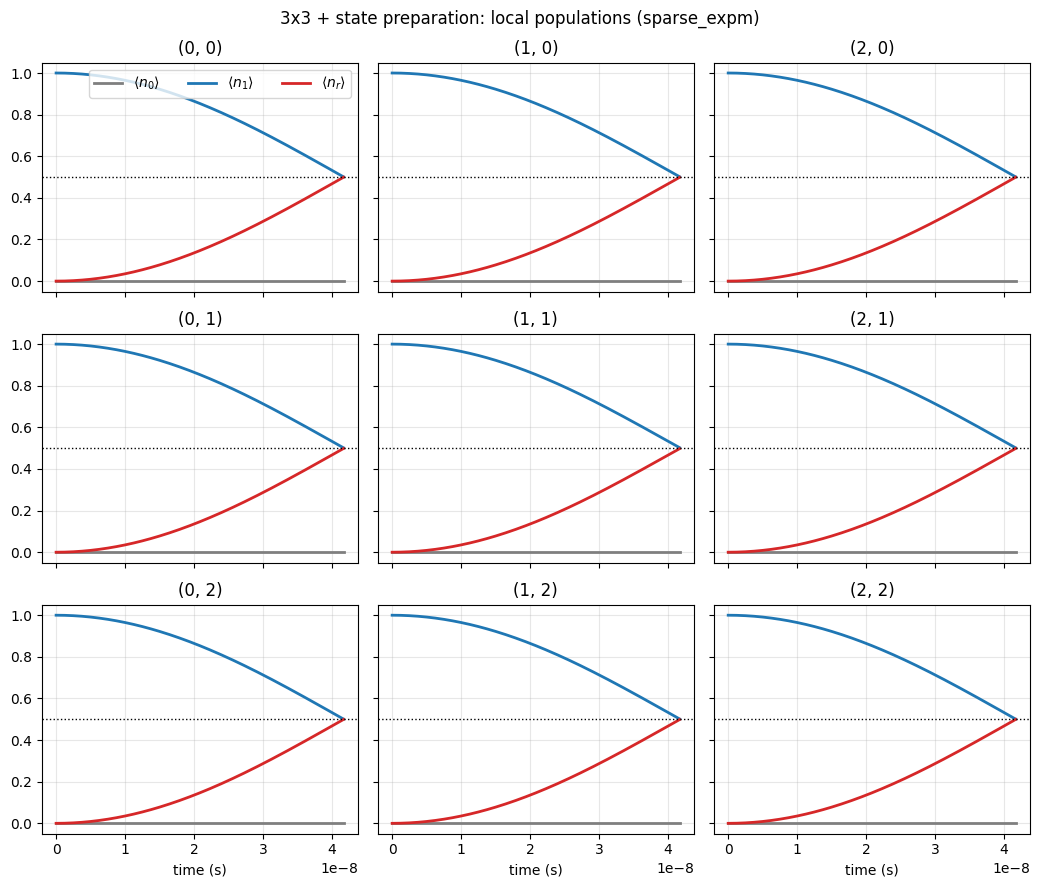

In [6]:
# Stage 1: plus-state preparation through the unified RydbergSystem API.
# The level spectrum is declared once in RydbergSystem.from_lattice(..., level_structure="01r").
# Changing sim_backend selects the compiler/simulator path; it does not change the spectrum.

Lx, Ly = 3, 3
spacing = 10.0
N = Lx * Ly

prep_proto = DigitalAnalogProtocol([full_segments[0]], n_steps=200)
geom = make_square_lattice(Lx, Ly, spacing_um=spacing)
system = RydbergSystem.from_lattice(
    geom,
    level_structure="01r",
    interaction=InteractionSpec(C6=DEFAULT_C6, mode="all"),
    protocol=prep_proto,
    Omega=OMEGA_R,
)

# "sparse_expm": exact state-vector evolution (small N only).
# "tenpy" / "gputn": TN TDVP for larger lattices.
sim_backend = "sparse_expm"
# sim_backend = "tenpy"
t_eval_prep = np.linspace(0.0, t_pi2_R, 101)

if sim_backend in {"tenpy", "gputn", "tn"}:
    backend_opts = {
        "chi_max": 128,
        "dt": t_pi2_R / prep_proto.n_steps,
        "svd_min": 1e-10,
    }
    res_prep = simulate(
        system,
        [],
        "all_1",
        backend=sim_backend,
        backend_options=backend_opts,
        method="tdvp",
        t_eval=t_eval_prep,
        observables=["n_0", "n_1", "n_i", "n_mean"],
    )
    t_prep = res_prep.times
    psi_plus_init = res_prep.psi_final
    spec = res_prep.metadata["tn_spec"]
    psi_plus_target = product_superposition_mps(
        spec,
        ground_amp=1 / np.sqrt(2),
        rydberg_amp=-1j / np.sqrt(2),
    )
    fid_prep = mps_fidelity(psi_plus_target, psi_plus_init)
    n_0_prep = res_prep.metadata["obs"]["n_0"]
    n_1_prep = res_prep.metadata["obs"]["n_1"]
    n_r_prep = res_prep.metadata["obs"]["n_i"]
else:
    backend_opts = {"n_steps": prep_proto.n_steps}
    res_prep = simulate(
        system,
        [],
        "all_1",
        backend=sim_backend,
        backend_options=backend_opts,
        t_eval=t_eval_prep,
    )
    psi0 = system.product_state(["1"] * N)
    t_prep = np.concatenate([[0.0], res_prep.times])
    states = [psi0, *res_prep.states]
    n_0_prep = np.array(
        [[system.expectation(f"n_0_{i}", psi) for i in range(N)] for psi in states]
    )
    n_1_prep = np.array(
        [[system.expectation(f"n_1_{i}", psi) for i in range(N)] for psi in states]
    )
    n_r_prep = np.array(
        [[system.expectation(f"n_r_{i}", psi) for i in range(N)] for psi in states]
    )
    psi_plus_init = res_prep.psi_final
    psi_plus_target = sum(
        (-1j) ** sum(c == "r" for c in cfg) * system.product_state(list(cfg))
        for cfg in product(["1", "r"], repeat=N)
    ) / (2 ** (N / 2))
    fid_prep = np.abs(np.vdot(psi_plus_target, psi_plus_init)) ** 2

print(f"N={N}, prep-end fidelity to (|1> - i|r>)/sqrt(2)^{N}: {fid_prep:.4f}")

BS = chr(92)
colors = {"0": "tab:gray", "1": "tab:blue", "r": "tab:red"}
if N <= 25:
    fig, axes = plt.subplots(Ly, Lx, figsize=(3.5 * Lx, 3 * Ly), sharex=True, sharey=True)
    axes = np.asarray(axes).reshape(Ly, Lx)
    for i in range(N):
        ix, iy = i // Ly, i % Ly
        ax = axes[iy, ix]
        ax.plot(t_prep, n_0_prep[:, i], color=colors["0"], lw=2, label=f"${BS}langle n_0{BS}rangle$")
        ax.plot(t_prep, n_1_prep[:, i], color=colors["1"], lw=2, label=f"${BS}langle n_1{BS}rangle$")
        ax.plot(t_prep, n_r_prep[:, i], color=colors["r"], lw=2, label=f"${BS}langle n_r{BS}rangle$")
        ax.axhline(0.5, color="k", ls=":", lw=1)
        ax.set_title(f"({ix}, {iy})")
        ax.grid(alpha=0.3)
        if i == 0:
            ax.legend(loc="upper right", ncol=3)
    for ax in axes[-1, :]:
        ax.set_xlabel("time (s)")
    fig.suptitle(f"{Lx}x{Ly} + state preparation: local populations ({sim_backend})")
else:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(t_prep, n_r_prep.mean(axis=1), color="tab:red", lw=2)
    axes[0].axhline(0.5, color="k", ls=":", lw=1)
    axes[0].set_xlabel("time (s)")
    axes[0].set_ylabel(f"mean ${BS}langle n_r{BS}rangle$")
    axes[0].grid(alpha=0.3)

    im1 = axes[1].imshow(n_r_prep[-1].reshape(Lx, Ly).T, origin="lower", vmin=0, vmax=1, cmap="Reds")
    axes[1].set_title(f"prep end ${BS}langle n_r{BS}rangle$")
    axes[1].set_xlabel("ix")
    axes[1].set_ylabel("iy")
    fig.colorbar(im1, ax=axes[1], shrink=0.85)

    im2 = axes[2].imshow(n_1_prep[-1].reshape(Lx, Ly).T, origin="lower", vmin=0, vmax=1, cmap="Blues")
    axes[2].set_title(f"prep end ${BS}langle n_1{BS}rangle$")
    axes[2].set_xlabel("ix")
    axes[2].set_ylabel("iy")
    fig.colorbar(im2, ax=axes[2], shrink=0.85)

    fig.suptitle(f"{Lx}x{Ly} + state preparation: observables ({sim_backend})")
plt.tight_layout()
plt.show()


## Sublattice-X echo strategies

Benchmark two sublattice echo protocols on the same central `01r` spectrum. Each strategy is split into two executable cells: first build and show the pulse schedule, then run the selected backend and compute fidelity.


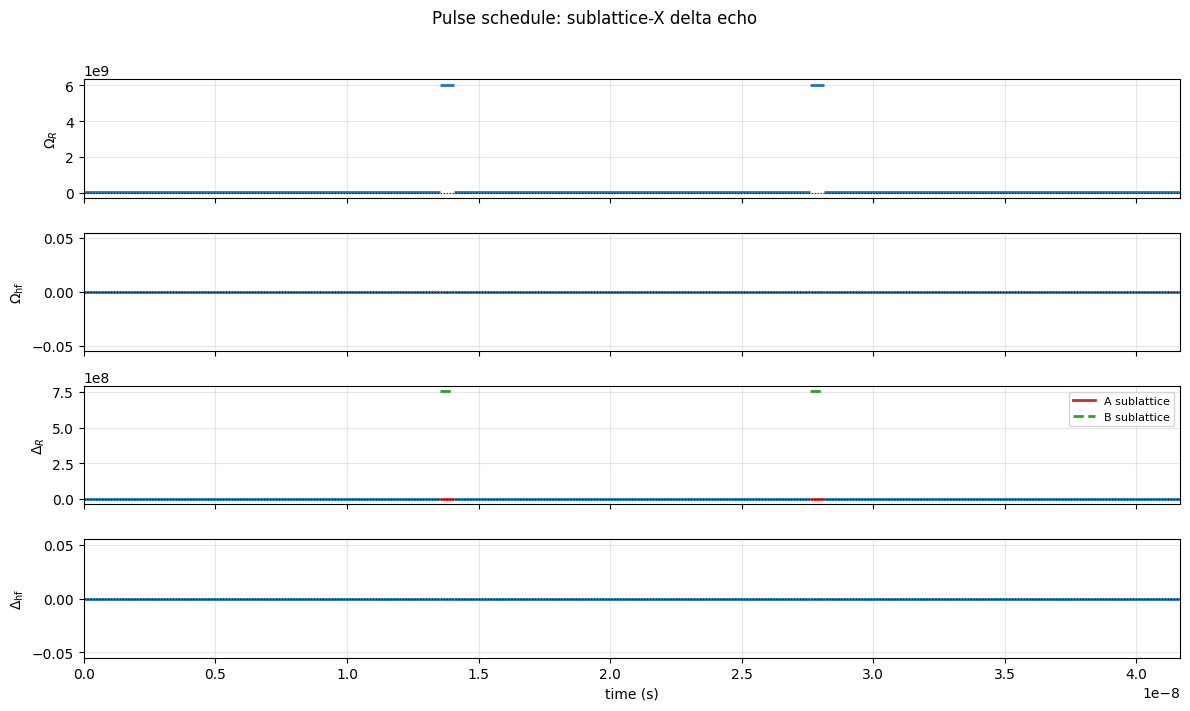

In [ ]:
# Delta echo pulse schedule
# Uses sim_backend from Stage 1: "sparse_expm" for small lattices, "tenpy"/"gputn" for TN.

Lx,  Ly = 3, 3
spacing = 10.0
N =  Lx *  Ly
chi_max = 32
steps = 24
dt = t_pi2_R /  steps
echo_M = 2
echo_width = t_pi2_R / 80
off_detuning = 20 * OMEGA_R
echo_interaction_mode = "nn"
V_nn_echo = DEFAULT_C6 /  spacing**6

mask_A = np.array([
    ((ix + iy) % 2 == 0)
    for ix in range( Lx)
    for iy in range( Ly)
], dtype=bool)
mask_B = ~mask_A

if echo_M < 0:
    raise ValueError(" echo_M must be nonnegative")
if echo_M *  echo_width >= t_pi2_R:
    raise ValueError("Echo pulse width is too large for the preparation window.")

if echo_M == 0:
    delta_echo_segments = [Segment(duration=t_pi2_R, omega_R=OMEGA_R)]
else:
    delta_echo_interval = (t_pi2_R -  echo_M *  echo_width) / ( echo_M + 1)
    delta_echo_x_omega = np.pi /  echo_width
    delta_echo_segments = []
    for _ in range(echo_M):
        delta_echo_segments.append(Segment(duration=delta_echo_interval, omega_R=OMEGA_R))
        delta_echo_segments.append(
            Segment(
                duration= echo_width,
                omega_R=delta_echo_x_omega,
                delta_R=np.where(mask_A, 0.0,  off_detuning),
            )
        )
    delta_echo_segments.append(Segment(duration=delta_echo_interval, omega_R=OMEGA_R))

delta_echo_proto = DigitalAnalogProtocol(
    delta_echo_segments,
    n_steps=max( steps, 20 * len(delta_echo_segments)),
)

delta_echo_edges = [0.0]
for seg in delta_echo_proto.segments:
    delta_echo_edges.append(delta_echo_edges[-1] + seg.duration)
delta_echo_t_gate = delta_echo_edges[-1]

fig_de, axes_de = plt.subplots(4, 1, figsize=(12, 7), sharex=True)
for ax_de, (field, label) in zip(axes_de, _proto_fields):
    plotted_ab = False
    for j, seg in enumerate(delta_echo_proto.segments):
        prof = np.asarray(getattr(seg, field), dtype=float)
        if prof.ndim == 0:
            prof = np.full( N, float(prof))
        if prof.shape != ( N,):
            raise ValueError(f"{field} must be scalar or length-{ N}; got {prof.shape}.")
        t0, t1 = delta_echo_edges[j], delta_echo_edges[j + 1]
        if np.allclose(prof, prof[0]):
            ax_de.hlines(prof[0], t0, t1, colors="tab:blue", lw=2)
        else:
            ax_de.hlines(prof[mask_A].mean(), t0, t1, colors="tab:red", lw=2)
            ax_de.hlines(prof[mask_B].mean(), t0, t1, colors="tab:green", lw=2, ls="--")
            plotted_ab = True
    if plotted_ab:
        ax_de.plot([], [], color="tab:red", lw=2, label="A sublattice")
        ax_de.plot([], [], color="tab:green", lw=2, ls="--", label="B sublattice")
        ax_de.legend(loc="upper right", fontsize=8)
    ax_de.axhline(0.0, color="k", ls=":", lw=0.8)
    ax_de.set_ylabel(label)
    ax_de.grid(alpha=0.3)
    ax_de.set_xlim(0.0, delta_echo_t_gate)
axes_de[-1].set_xlabel("time (s)")
fig_de.suptitle("Pulse schedule: sublattice-X delta echo", y=1.01)
plt.tight_layout()
plt.show()


sublattice-X delta echo: F=0.033162, <n_r>_final=0.9627, t_gate=4.17e-08 s


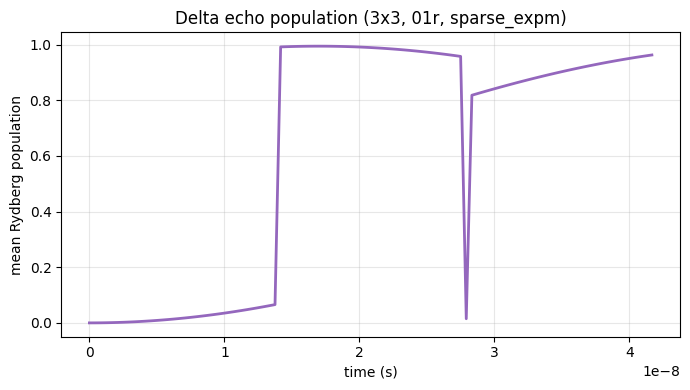

In [ ]:
# Delta echo fidelity

geom_delta = make_square_lattice( Lx,  Ly, spacing_um= spacing)
system_delta = RydbergSystem.from_lattice(
    geom_delta,
    level_structure="01r",
    interaction=InteractionSpec(C6=DEFAULT_C6, mode= echo_interaction_mode),
    protocol=delta_echo_proto,
    Omega=OMEGA_R,
)
t_eval_delta = np.linspace(0.0, delta_echo_proto._t_gate, 25)
sim_backend = "sparse_expm"
if sim_backend in {"tenpy", "gputn", "tn"}:
    delta_dt = min( dt, delta_echo_proto._t_gate / max(1,  steps))
    res_delta = simulate(
        system_delta,
        [],
        "all_1",
        backend=sim_backend,
        backend_options={"chi_max":  chi_max, "dt": delta_dt, "svd_min": 1e-10},
        method="tdvp",
        t_eval=t_eval_delta,
        observables=["n_0", "n_1", "n_i", "n_mean"],
    )
    spec_delta = res_delta.metadata["tn_spec"]
    target_delta = product_superposition_mps(
        spec_delta,
        zero_amp=0.0,
        ground_amp=1 / np.sqrt(2),
        rydberg_amp=-1j / np.sqrt(2),
    )
    fid_delta = mps_fidelity(target_delta, res_delta.psi_final)
    t_delta = res_delta.times
    n_r_delta_mean = res_delta.metadata["obs"]["n_i"].mean(axis=1)
else:
    res_delta = simulate(
        system_delta,
        [],
        "all_1",
        backend=sim_backend,
        backend_options={"n_steps": delta_echo_proto.n_steps},
        t_eval=t_eval_delta,
    )
    target_delta = sum(
        (-1j) ** sum(c == "r" for c in cfg) * system_delta.product_state(list(cfg))
        for cfg in product(["1", "r"], repeat= N)
    ) / (2 ** ( N / 2))
    fid_delta = float(np.abs(np.vdot(target_delta, res_delta.psi_final)) ** 2)
    psi0_delta = system_delta.product_state(["1"] *  N)
    t_delta = np.concatenate([[0.0], res_delta.times])
    states_delta = [psi0_delta, *res_delta.states]
    n_r_delta_mean = np.array([
        np.mean([system_delta.expectation(f"n_r_{i}", psi) for i in range( N)])
        for psi in states_delta
    ])

final_n_r_delta = float(n_r_delta_mean[-1])
delta_echo_row = {
    "strategy": "sublattice-X delta echo",
    "fidelity": fid_delta,
    "times": t_delta,
    "n_r_mean": n_r_delta_mean,
    "final_n_r_mean": final_n_r_delta,
    "t_gate": delta_echo_proto._t_gate,
}
echo_comparison = [row for row in globals().get("echo_comparison", []) if row["strategy"] != delta_echo_row["strategy"]]
echo_comparison.append(delta_echo_row)

print(
    f"{delta_echo_row['strategy']}: "
    f"F={fid_delta:.6f}, "
    f"<n_r>_final={final_n_r_delta:.4f}, "
    f"t_gate={delta_echo_proto._t_gate:.2e} s"
)

fig_delta, ax_delta = plt.subplots(figsize=(7, 4))
ax_delta.plot(t_delta, n_r_delta_mean, lw=2, color="tab:purple")
ax_delta.set_xlabel("time (s)")
ax_delta.set_ylabel("mean Rydberg population")
ax_delta.set_title(f"Delta echo population ({ Lx}x{ Ly}, 01r, {sim_backend})")
ax_delta.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# Ordered echo pulse schedule

 Lx,  Ly = 3, 3
 spacing = 10.0
 N =  Lx *  Ly
 chi_max = 32
 steps = 24
 dt = t_pi2_R /  steps
 off_detuning = 20 * OMEGA_R
 echo_interaction_mode = "nn"
V_nn_echo = DEFAULT_C6 /  spacing**6
ordered_z_max = 4

mask_A = np.array([
    ((ix + iy) % 2 == 0)
    for ix in range( Lx)
    for iy in range( Ly)
], dtype=bool)
mask_B = ~mask_A

ordered_echo_segments = [
    Segment(
        duration=t_pi2_R,
        omega_R=OMEGA_R,
        delta_R=np.where(mask_A, 0.0,  off_detuning),
    ),
]
for k in range(ordered_z_max + 1):
    ordered_echo_segments.append(
        Segment(
            duration=t_pi2_R,
            omega_R=OMEGA_R,
            delta_R=np.where(mask_B, k * V_nn_echo,  off_detuning),
        )
    )

ordered_echo_proto = DigitalAnalogProtocol(
    ordered_echo_segments,
    n_steps=max( steps, 20 * len(ordered_echo_segments)),
)

ordered_echo_edges = [0.0]
for seg in ordered_echo_proto.segments:
    ordered_echo_edges.append(ordered_echo_edges[-1] + seg.duration)
ordered_echo_t_gate = ordered_echo_edges[-1]

fig_oe, axes_oe = plt.subplots(4, 1, figsize=(12, 7), sharex=True)
for ax_oe, (field, label) in zip(axes_oe, _proto_fields):
    plotted_ab = False
    for j, seg in enumerate(ordered_echo_proto.segments):
        prof = np.asarray(getattr(seg, field), dtype=float)
        if prof.ndim == 0:
            prof = np.full( N, float(prof))
        if prof.shape != ( N,):
            raise ValueError(f"{field} must be scalar or length-{ N}; got {prof.shape}.")
        t0, t1 = ordered_echo_edges[j], ordered_echo_edges[j + 1]
        if np.allclose(prof, prof[0]):
            ax_oe.hlines(prof[0], t0, t1, colors="tab:blue", lw=2)
        else:
            ax_oe.hlines(prof[mask_A].mean(), t0, t1, colors="tab:red", lw=2)
            ax_oe.hlines(prof[mask_B].mean(), t0, t1, colors="tab:green", lw=2, ls="--")
            plotted_ab = True
    if plotted_ab:
        ax_oe.plot([], [], color="tab:red", lw=2, label="A sublattice")
        ax_oe.plot([], [], color="tab:green", lw=2, ls="--", label="B sublattice")
        ax_oe.legend(loc="upper right", fontsize=8)
    ax_oe.axhline(0.0, color="k", ls=":", lw=0.8)
    ax_oe.set_ylabel(label)
    ax_oe.grid(alpha=0.3)
    ax_oe.set_xlim(0.0, ordered_echo_t_gate)
axes_oe[-1].set_xlabel("time (s)")
fig_oe.suptitle("Pulse schedule: sublattice-X ordered echo", y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
# Ordered echo fidelity

geom_ordered = make_square_lattice( Lx,  Ly, spacing_um= spacing)
system_ordered = RydbergSystem.from_lattice(
    geom_ordered,
    level_structure="01r",
    interaction=InteractionSpec(C6=DEFAULT_C6, mode= echo_interaction_mode),
    protocol=ordered_echo_proto,
    Omega=OMEGA_R,
)
t_eval_ordered = np.linspace(0.0, ordered_echo_proto._t_gate, 25)

if sim_backend in {"tenpy", "gputn", "tn"}:
    ordered_dt = min( dt, ordered_echo_proto._t_gate / max(1,  steps))
    res_ordered = simulate(
        system_ordered,
        [],
        "all_1",
        backend=sim_backend,
        backend_options={"chi_max":  chi_max, "dt": ordered_dt, "svd_min": 1e-10},
        method="tdvp",
        t_eval=t_eval_ordered,
        observables=["n_0", "n_1", "n_i", "n_mean"],
    )
    spec_ordered = res_ordered.metadata["tn_spec"]
    target_ordered = product_superposition_mps(
        spec_ordered,
        zero_amp=0.0,
        ground_amp=1 / np.sqrt(2),
        rydberg_amp=-1j / np.sqrt(2),
    )
    fid_ordered = mps_fidelity(target_ordered, res_ordered.psi_final)
    t_ordered = res_ordered.times
    n_r_ordered_mean = res_ordered.metadata["obs"]["n_i"].mean(axis=1)
else:
    res_ordered = simulate(
        system_ordered,
        [],
        "all_1",
        backend=sim_backend,
        backend_options={"n_steps": ordered_echo_proto.n_steps},
        t_eval=t_eval_ordered,
    )
    target_ordered = sum(
        (-1j) ** sum(c == "r" for c in cfg) * system_ordered.product_state(list(cfg))
        for cfg in product(["1", "r"], repeat= N)
    ) / (2 ** ( N / 2))
    fid_ordered = float(np.abs(np.vdot(target_ordered, res_ordered.psi_final)) ** 2)
    psi0_ordered = system_ordered.product_state(["1"] *  N)
    t_ordered = np.concatenate([[0.0], res_ordered.times])
    states_ordered = [psi0_ordered, *res_ordered.states]
    n_r_ordered_mean = np.array([
        np.mean([system_ordered.expectation(f"n_r_{i}", psi) for i in range( N)])
        for psi in states_ordered
    ])

final_n_r_ordered = float(n_r_ordered_mean[-1])
ordered_echo_row = {
    "strategy": "sublattice-X ordered echo",
    "fidelity": fid_ordered,
    "times": t_ordered,
    "n_r_mean": n_r_ordered_mean,
    "final_n_r_mean": final_n_r_ordered,
    "t_gate": ordered_echo_proto._t_gate,
}
echo_comparison = [row for row in globals().get("echo_comparison", []) if row["strategy"] != ordered_echo_row["strategy"]]
echo_comparison.append(ordered_echo_row)

print(
    f"{ordered_echo_row['strategy']}: "
    f"F={fid_ordered:.6f}, "
    f"<n_r>_final={final_n_r_ordered:.4f}, "
    f"t_gate={ordered_echo_proto._t_gate:.2e} s"
)
print(f"Best fidelity: {max(echo_comparison, key=lambda x: x['fidelity'])['strategy']}")

fig_echo, axes_echo = plt.subplots(1, 2, figsize=(12, 4))
labels = [row["strategy"] for row in echo_comparison]
fids = [row["fidelity"] for row in echo_comparison]
bar_colors = ["tab:purple", "tab:brown"][:len(echo_comparison)]
axes_echo[0].bar(labels, fids, color=bar_colors)
axes_echo[0].set_ylim(max(0.0, min(fids) - 0.05), 1.005)
axes_echo[0].set_ylabel("target fidelity")
axes_echo[0].tick_params(axis="x", rotation=15)
axes_echo[0].grid(axis="y", alpha=0.3)
for idx, fid in enumerate(fids):
    axes_echo[0].text(idx, fid, f"{fid:.3f}", ha="center", va="bottom", fontsize=9)

for row in echo_comparison:
    axes_echo[1].plot(row["times"], row["n_r_mean"], lw=2, label=row["strategy"])
axes_echo[1].set_xlabel("time (s)")
axes_echo[1].set_ylabel("mean Rydberg population")
axes_echo[1].grid(alpha=0.3)
axes_echo[1].legend(fontsize=8)
fig_echo.suptitle(f"Sublattice-X echo benchmark ({ Lx}x{ Ly}, 01r, {sim_backend})")
plt.tight_layout()
plt.show()


In [ ]:
# Stage 2: Ising evolution using the prep final state as initial condition
# H = sum_{i<j} V_ij n_i^r n_j^r - Delta_R * sum_i n_i^r

ising_proto = DigitalAnalogProtocol([full_segments[1]], n_steps=200)
ising_system = system.with_protocol(ising_proto)
t_eval_ising = np.linspace(0.0, T_ISING, 101)

if sim_backend in {"tenpy", "gputn", "tn"}:
    ising_opts = {**backend_opts, "dt": min(backend_opts["dt"], T_ISING / 200)}
    res_ising = simulate(
        ising_system,
        [],
        psi_plus_init,
        backend=sim_backend,
        backend_options=ising_opts,
        method="tdvp",
        t_eval=t_eval_ising,
        observables=["n_i", "n_mean"],
    )
    t_ising = res_ising.times
    n_r_ising = res_ising.metadata["obs"]["n_i"]
else:
    ising_opts = {"n_steps": ising_proto.n_steps}
    res_ising = simulate(
        ising_system,
        [],
        psi_plus_init,
        backend=sim_backend,
        backend_options=ising_opts,
        t_eval=t_eval_ising,
    )
    t_ising = np.concatenate([[0.0], res_ising.times])
    states_ising = [psi_plus_init, *res_ising.states]
    n_r_ising = np.array(
        [[system.expectation(f"n_r_{i}", psi) for i in range(N)] for psi in states_ising]
    )

# Stitch full trajectory (prep + ising), dropping the duplicated t=0 of the second stage.
t_offset = t_prep[-1]
t_full = np.concatenate([t_prep, t_offset + t_ising[1:]])
n_r_full = np.vstack([n_r_prep, n_r_ising[1:]])

if N <= 25:
    fig, axes = plt.subplots(Ly, Lx, figsize=(3.5 * Lx, 3 * Ly), sharex=True, sharey=True)
    axes = np.asarray(axes).reshape(Ly, Lx)
    for i in range(N):
        ix, iy = i // Ly, i % Ly
        ax = axes[iy, ix]
        ax.plot(t_full, n_r_full[:, i], color="tab:red", lw=2, label=f"${BS}langle n_r{BS}rangle$")
        ax.axvline(t_prep_end, color="tab:orange", ls="--", lw=1, alpha=0.8)
        ax.set_title(f"({ix}, {iy})")
        ax.grid(alpha=0.3)
        if i == 0:
            ax.legend(loc="upper right")
    for ax in axes[-1, :]:
        ax.set_xlabel("time (s)")
    fig.suptitle(f"Full process local Rydberg density: prep + Ising evolution ({Lx}x{Ly}, {sim_backend})")
else:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(t_full, n_r_full.mean(axis=1), color="tab:red", lw=2)
    axes[0].axvline(t_prep_end, color="tab:orange", ls="--", lw=1, alpha=0.8)
    axes[0].set_xlabel("time (s)")
    axes[0].set_ylabel(f"mean ${BS}langle n_r{BS}rangle$")
    axes[0].grid(alpha=0.3)

    im1 = axes[1].imshow(n_r_full[len(t_prep) - 1].reshape(Lx, Ly).T, origin="lower", vmin=0, vmax=1, cmap="Reds")
    axes[1].set_title(f"after prep ${BS}langle n_r{BS}rangle$")
    axes[1].set_xlabel("ix")
    axes[1].set_ylabel("iy")
    fig.colorbar(im1, ax=axes[1], shrink=0.85)

    im2 = axes[2].imshow(n_r_full[-1].reshape(Lx, Ly).T, origin="lower", vmin=0, vmax=1, cmap="Reds")
    axes[2].set_title(f"final ${BS}langle n_r{BS}rangle$")
    axes[2].set_xlabel("ix")
    axes[2].set_ylabel("iy")
    fig.colorbar(im2, ax=axes[2], shrink=0.85)

    fig.suptitle(f"Full process Rydberg density: prep + Ising evolution ({Lx}x{Ly}, {sim_backend})")
plt.tight_layout()
plt.show()

final_n_r = n_r_full[-1]
print("Final local rydberg density <n_r_i>(t_final):")
print(f"  mean={final_n_r.mean():.6f}, min={final_n_r.min():.6f}, max={final_n_r.max():.6f}")
if N <= 25:
    for i in range(N):
        print(f"  site {i}: {final_n_r[i]:.6f}")
else:
    for i in range(min(10, N)):
        print(f"  site {i}: {final_n_r[i]:.6f}")
    print(f"  ... {N - min(10, N)} more sites")
